# Characterization of the pH-Dependent Stabilizing Forces of Insulin’s Monomeric and Fibril States  
Stefan Hervø-Hansen<sup>a</sup> and Nobuyuki Matubayasi<sup>a</sup><br><br>
<sup>a</sup>Division of Chemical Engineering, Graduate School of Engineering Science, The University of Osaka, Toyonaka, Osaka 560-8531, Japan.<br>
*Correspondence:* stefan@cheng.es.osaka-u.ac.jp, nobuyuki@cheng.es.osaka-u.ac.jp

---

## Part 1: Monomeric Native State
**Purpose:** CpHMD analysis of monomeric insulin titration behavior.

---

### Project Notebook Index

| Notebook | Description |
|---------|-------------|
| [Simulations](./Simulations.ipynb) | Equilibration analysis and simulation quality assessment |
| [Analysis_monomer](./Analysis_monomer.ipynb) | CpHMD analysis of monomeric native insulin |
| [Analysis_fibril_1mer](./Analysis_fibril_1mer.ipynb) | CpHMD analysis of fibril protofilament (1-mer) |
| [Analysis_fibril_3mer](./Analysis_fibril_3mer.ipynb) | CpHMD analysis of fibril trimer (3-mer) |
| [Analysis_fibril_7mer](./Analysis_fibril_7mer.ipynb) | CpHMD analysis of fibril heptamer (7-mer) |

---

### Module Loading and Function Definitions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.image as mpimg
import mdtraj as md
from scipy import stats
from scipy import optimize
from scipy.interpolate import interp1d
from IPython.display import Markdown
from tqdm import tqdm, trange
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'


In [2]:
def Hill_Henderson_Hasselbalch(pH, pKa, n):
    """
    Generalized Henderson–Hasselbalch equation including Hill coefficient.

    Computes the fraction of the deprotonated state of an ionizable group 
    using the Hill-modified Henderson–Hasselbalch equation.

    Parameters:
        pH (float or np.ndarray): The pH value(s).
        pKa (float): The acid dissociation constant (pKa) of the titratable group.
        n (float): Hill coefficient, representing cooperativity. 
                   n = 1 implies no cooperativity, 
                   n < 1 implies anti-cooperativity, 
                   n > 1 implies cooperativity.

    Returns:
        float or np.ndarray: The fraction of the deprotonated species at the given pH.
    """
    return 1 / (1 + 10**(n * (pKa - pH)))

def block_avg_histogram(data, n_blocks, bins=20, hist_range=None, density=True):
    """
    Compute a block-averaged histogram with 95% confidence interval based on t-distribution.

    Parameters:
        data (np.ndarray): 1D input data (angles, distances, SASA, etc.).
        n_blocks (int): Number of blocks to divide the data into.
        bins (int): Number of histogram bins.
        hist_range (tuple or None): Tuple specifying histogram bin range (min, max).
                                   If None, uses (min(data), max(data)).
        density (bool): If True, returns probability density (area = 1).
                        If False, returns raw counts.

    Returns:
        bin_centers (np.ndarray): Midpoints of histogram bins.
        mean_hist (np.ndarray): Mean histogram values across blocks.
        ci95 (np.ndarray): 95% confidence interval of histogram values, 
                           computed assuming approximate normality of block means.

    Notes:
        The 95% confidence interval is calculated using the standard error of the mean (SEM)
        across blocks and the t-distribution quantile. This approach assumes that the block means
        are approximately normally distributed, which is justified by the Central Limit Theorem
        when blocks are sufficiently large and approximately independent.
        If this assumption is violated (e.g., for very small block sizes or strongly skewed data),
        alternative methods such as bootstrap confidence intervals may be more appropriate.
    """
    n_frames = len(data)
    frames_per_block = n_frames // n_blocks
    if frames_per_block < 1:
        raise ValueError("Too many blocks or too few data points.")

    # Trim excess frames and reshape
    data_trimmed = data[:n_blocks * frames_per_block]
    data_blocks = data_trimmed.reshape(n_blocks, frames_per_block)

    # Auto-range if not provided
    if hist_range is None:
        data_min, data_max = np.min(data), np.max(data)
        bin_edges = np.linspace(data_min, data_max, bins + 1)
    else:
        bin_edges = np.linspace(hist_range[0], hist_range[1], bins + 1)

    # Compute histogram for each block
    histograms = np.zeros((n_blocks, bins))
    for i in range(n_blocks):
        hist, _ = np.histogram(data_blocks[i], bins=bin_edges, density=density)
        histograms[i] = hist

    # Mean and 95% CI
    mean_hist = histograms.mean(axis=0)
    ci95 = stats.t.ppf(0.975, n_blocks - 1) * stats.sem(histograms, axis=0)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    return bin_centers, mean_hist, ci95

def get_atom_index(residue_name, res_index, atom_name):
    for atom in top.atoms:
        if atom.residue.index == res_index and atom.name == atom_name and atom.residue.name.startswith(residue_name):
            return atom.index
    raise ValueError(f"{residue_name}{res_index}:{atom_name} not found")


## Insulin residue metadata (canonical labeling)
This cell constructs a canonical residue mapping directly from the simulation topology (`insulin_leap_output.pdb`).
The goal is to avoid hard-coded indices and instead work with biologically meaningful identities:

- chain index
- residue sequence number (resSeq from PDB)
- residue name

From this topology we generate:

- `residue_table`: all residues in the system
- `titratable_residues`: residues included in CpHMD/SASA analysis
- `glu_residues`: GL4 residues only (used for plotting and comparison)
- `titratable_indices`: topology indices in the exact order used for SASA arrays
- `glu_columns`: column indices inside SASA `.npy` files corresponding to GL4
- `glu_residue_labels`: human-readable labels for plots (e.g. GL4 0:18)

These objects form the biological reference layer for all subsequent analysis and guarantee consistent labeling across monomer and protofibril systems, even when residues are missing or constructs differ.

In [3]:
# ============================================================
# Canonical mature human insulin
# ============================================================

INSULIN_B = "FVNQHLCGSHLVEALYLVCGERGFFYTPKT"   # 30
INSULIN_A = "GIVEQCCTSICSLYQLENYCN"           # 21

CANONICAL = {"A": INSULIN_A, "B": INSULIN_B}

# ============================================================
# Residue mappings
# ============================================================

AA3_TO_AA1 = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLU":"E","GL4":"E",
    "GLN":"Q","GLY":"G","HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M",
    "PHE":"F","PRO":"P","SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V"
}

DISPLAY_RESNAME = {
    "GL4":"Glu","GLU":"Glu","ASP":"Asp","HIS":"His",
    "TYR":"Tyr","LYS":"Lys","CYS":"Cys"
}

TITRATABLE = {"GL4","HIS","LYS","TYR"}

# ============================================================
# Load topology
# ============================================================

topology = md.load("monomer/0_preparation/insulin_leap_output.pdb")
topology.remove_solvent(inplace=True)
top = topology.topology

# ============================================================
# Build residue table
# ============================================================

residue_table = []

for res in top.residues:

    aa1 = AA3_TO_AA1.get(res.name, "X")
    display = DISPLAY_RESNAME.get(res.name, res.name.title())

    residue_table.append({
        "top_index": res.index,
        "chain": res.chain.index,
        "resSeq": res.resSeq,
        "resname": res.name,
        "display_name": display,
        "oneletter": aa1
    })

# ============================================================
# Assign biological chains (A/B by length)
# ============================================================

chains = sorted(set(r["chain"] for r in residue_table))

chain_lengths = {
    c: sum(1 for r in residue_table if r["chain"] == c)
    for c in chains
}

sorted_chains = sorted(chain_lengths.items(), key=lambda x: x[1])

chain_map = {
    sorted_chains[0][0]: "A",
    sorted_chains[1][0]: "B"
}

for r in residue_table:
    r["bio_chain"] = chain_map[r["chain"]]

# ============================================================
# Assign canonical indices + mutation check
# ============================================================

for chain in ["A","B"]:

    canon = CANONICAL[chain]
    chain_res = [r for r in residue_table if r["bio_chain"] == chain]
    chain_res.sort(key=lambda x: x["resSeq"])

    for i,r in enumerate(chain_res):

        if i < len(canon):
            r["canonical_index"] = i+1
            r["canonical_aa"] = canon[i]
            r["matches_canonical"] = (r["oneletter"] == canon[i])
        else:
            r["canonical_index"] = None
            r["canonical_aa"] = None
            r["matches_canonical"] = False

# ============================================================
# Canonical labels for plotting
# ============================================================

for r in residue_table:
    if r["canonical_index"] is not None:
        r["canonical_label"] = f"{r['display_name']} {r['bio_chain']}:{r['canonical_index']}"
    else:
        r["canonical_label"] = None

# ============================================================
# Report mutations
# ============================================================

print("\nResidue mismatches vs canonical insulin:\n")

for r in residue_table:
    if r["canonical_aa"] and not r["matches_canonical"]:
        print(f"{r['bio_chain']}{r['canonical_index']} expected {r['canonical_aa']} found {r['oneletter']}")

# ============================================================
# Titratable residues
# ============================================================

titr_res = [r for r in residue_table if r["resname"] in TITRATABLE]
titr_indices = [r["top_index"] for r in titr_res]
residue_labels = [r["canonical_label"] for r in titr_res]

# ---- expose standardized names for CpHMD ----
titratable_residues = titr_res
titratable_indices = titr_indices

# ============================================================
# Glutamates only (GL4)
# ============================================================

glu_residues = [r for r in titr_res if r["resname"] == "GL4"]
glu_residues.sort(key=lambda x:(x["bio_chain"],x["canonical_index"]))

glu_columns = [titr_indices.index(r["top_index"]) for r in glu_residues]
glu_labels = [r["canonical_label"] for r in glu_residues]

# ---- expose standardized name ----
glu_residue_labels = glu_labels

# ============================================================
# Sanity output
# ============================================================

print("\nGLU residues:")
for r in glu_residues:
    print(r["canonical_label"])

print("\nSequences detected:")

for chain in ["B","A"]:
    seq = "".join(r["oneletter"] for r in residue_table if r["bio_chain"]==chain)
    print(chain, seq)



Residue mismatches vs canonical insulin:

B30 expected T found A

GLU residues:
Glu A:4
Glu A:17
Glu B:13
Glu B:21

Sequences detected:
B FVNQHLCGSHLVEALYLVCGERGFFYTPKA
A GIVEQCCTSICSLYQLENYCN


## Loading CpHMD titration data
This section parses Amber constant-pH output (`cpout`) files and computes block-averaged protonation fractions for all titratable residues identified directly from the simulation topology.

Residue identities and canonical insulin labels (chain and position) are obtained from the previously constructed `residue_table`, ensuring consistency across monomeric and fibrillar systems, even when residues are missing or mutated.

Protonation states are converted into deprotonated fractions using residue-specific rules (acidic vs basic side chains).
The trajectory is divided into blocks to enable statistical analysis of protonation behavior as a function of pH.

In [4]:
# -----------------------------
# CpHMD titration loading
# -----------------------------

# Use titratable residues from metadata
titr_res = titratable_residues
n_residues = len(titr_res)

# Labels like: Glu A:4, His B:10, etc
residue_labels = [
    f"{r['display_name']} {r['bio_chain']}:{r['canonical_index']}"
    for r in titr_res
]

# Residue names for protonation logic
resnames = [r["resname"] for r in titr_res]

# Protonation logic

def is_deprotonated(resname, state):
    if resname in ["GLU", "ASP", "GL4"]:
        return state == 0
    elif resname in ["LYS", "TYR", "CYS"]:
        return state == 1
    elif resname == "HIS":
        return state != 0
    else:
        raise ValueError(f"Unknown residue type: {resname}")

# pH values
pHs = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0,
       8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5]

n_pHs = len(pHs)
n_blocks = 20
frames_total = 1200000
frames_per_block = frames_total // n_blocks

# counts[pH, block, residue]
counts = np.zeros((n_pHs, n_blocks, n_residues), dtype=int)

for i, pH in enumerate(pHs):

    filename = f"monomer/5_analysis/reordered_cpouts.pH_{pH:.2f}"

    if not os.path.isfile(filename):
        print(f"Missing: {filename}")
        continue

    with open(filename) as f:

        frame_counter = 0
        residue_counter = 0

        for line in f:

            if line.startswith("Residue"):

                tokens = line.split()
                res_index = int(tokens[1])
                state = int(tokens[-1])

                resname = resnames[res_index]

                if is_deprotonated(resname, state):
                    block_idx = frame_counter // frames_per_block
                    if block_idx < n_blocks:
                        counts[i, block_idx, res_index] += 1

                residue_counter += 1

                if residue_counter == n_residues:
                    frame_counter += 1
                    residue_counter = 0

# Fractions
fractions_deprotonated = counts / frames_per_block
fractions_protonated = 1.0 - fractions_deprotonated

# Save data
np.save('monomer/data/deprotonated_monomer.npy', fractions_deprotonated)

print("\nTitrating residues:")
for lab in residue_labels:
    print(lab)



Titrating residues:
Glu A:4
Tyr A:14
Glu A:17
Tyr A:19
His B:5
His B:10
Glu B:13
Tyr B:16
Glu B:21
Tyr B:26
Lys B:29


## Calculate p$K_a$ values and Hill coefficients

Block-averaged deprotonated fractions were fit independently for each residue using a Hill-modified Henderson–Hasselbalch equation.
Fits were performed separately for each block to estimate statistical uncertainty.

Reported p$K_a$ values and Hill coefficients correspond to the mean across blocks, with 95% confidence intervals computed from the standard error of the block distributions.


In [5]:
# -----------------------------
# Fit pKa + Hill coefficients
# -----------------------------

fitted_pkas = []
fitted_ns = []
errors_pkas = []
errors_ns = []

for r in range(n_residues):

    pka_block = []
    n_block = []

    for b in range(n_blocks):

        y = fractions_deprotonated[:, b, r]

        try:
            popt, _ = optimize.curve_fit(
                Hill_Henderson_Hasselbalch,
                pHs,
                y,
                p0=(7, 1),
                maxfev=10000
            )

            pka_block.append(popt[0])
            n_block.append(popt[1])

        except RuntimeError:
            continue

    pka_block = np.array(pka_block)
    n_block = np.array(n_block)

    N = len(pka_block)

    fitted_pkas.append(np.mean(pka_block))
    fitted_ns.append(np.mean(n_block))

    # 95% CI using Student-t
    if N > 1:
        errors_pkas.append(stats.t.ppf(0.975, N-1) * stats.sem(pka_block))
        errors_ns.append(stats.t.ppf(0.975, N-1) * stats.sem(n_block))
    else:
        errors_pkas.append(np.nan)
        errors_ns.append(np.nan)


# -----------------------------
# Markdown output
# -----------------------------
md_string = (
"| Residue | $\\mathrm{p}K_a \\pm 95\\%$ CI | $n_\\mathrm{H} \\pm 95\\%$ CI |\n"
"|---------|-----------------------------|-------------------------|\n"
)

for lab, pKa, pKa_err, n, n_err in zip(
        residue_labels,
        fitted_pkas,
        errors_pkas,
        fitted_ns,
        errors_ns):

    md_string += f"| {lab} | {pKa:.2f} ± {pKa_err:.2f} | {n:.2f} ± {n_err:.2f} |\n"

Markdown(md_string)


| Residue | $\mathrm{p}K_a \pm 95\%$ CI | $n_\mathrm{H} \pm 95\%$ CI |
|---------|-----------------------------|-------------------------|
| Glu A:4 | 4.38 ± 0.08 | 0.91 ± 0.04 |
| Tyr A:14 | 9.90 ± 0.02 | 1.02 ± 0.01 |
| Glu A:17 | 5.15 ± 0.07 | 0.88 ± 0.02 |
| Tyr A:19 | 12.23 ± 0.13 | 0.69 ± 0.03 |
| His B:5 | 6.45 ± 0.04 | 1.00 ± 0.01 |
| His B:10 | 6.64 ± 0.02 | 0.92 ± 0.01 |
| Glu B:13 | 4.27 ± 0.02 | 0.91 ± 0.01 |
| Tyr B:16 | 11.38 ± 0.02 | 0.95 ± 0.01 |
| Glu B:21 | 5.06 ± 0.03 | 0.91 ± 0.01 |
| Tyr B:26 | 11.83 ± 0.20 | 0.68 ± 0.04 |
| Lys B:29 | 10.41 ± 0.02 | 0.87 ± 0.02 |


## Visualize titration curves

Block-averaged deprotonated fractions are plotted as a function of pH for each titratable residue.
Residues are grouped by chemical type (Glu, Tyr, His, Lys), and mean Hill-model fits obtained from block analysis are overlaid.

Shaded confidence bands represent the 95% interval derived from block-resolved parameter distributions.


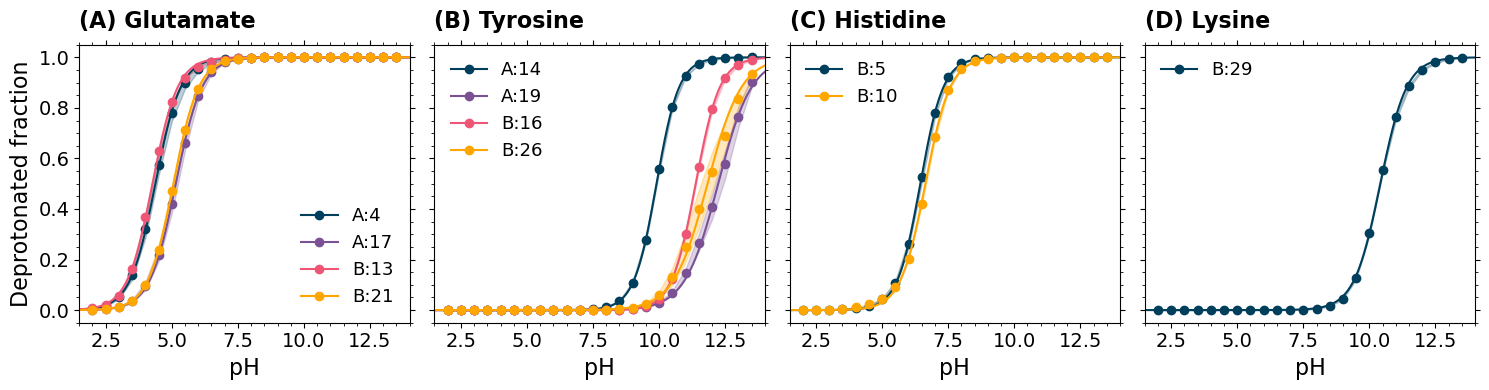

In [6]:
# -----------------------------
# Titration curve visualization
# -----------------------------

fig, axes = plt.subplots(1, 4, figsize=(1.5*10, 0.5*8), sharey=True)
axes_flat = axes.flatten()

full_palette = ['#003f5c', '#7a5195', '#ef5675', '#ffa600']

def get_colors(n, palette):
    if n == 1:
        return [palette[0]]
    elif n == 2:
        return [palette[0], palette[-1]]
    else:
        return [
            palette[int(round(i * (len(palette) - 1) / (n - 1)))]
            for i in range(n)
        ]

# -----------------------------
# Group residues by chemistry
# -----------------------------

residue_indices = {}

for i, r in enumerate(titr_res):
    display = DISPLAY_RESNAME.get(r["resname"], r["resname"])
    residue_indices.setdefault(display, []).append(i)

# Explicit plotting order
ordered_groups = ["Glu", "Tyr", "His", "Lys"]
index_groups = [residue_indices[g] for g in ordered_groups if g in residue_indices]

group_titles = [
    "(A) Glutamate",
    "(B) Tyrosine",
    "(C) Histidine",
    "(D) Lysine"
]

# Mean titration across blocks along with associated error
mean_titration_data = fractions_deprotonated.mean(axis=1)
err_titration_data = stats.t.ppf(0.975, df=N-1) * stats.sem(fractions_deprotonated, axis=1)

# -----------------------------
# Plot
# -----------------------------

for i, index_group in enumerate(index_groups):

    ax = axes_flat[i]
    group_colors = get_colors(len(index_group), full_palette)

    ax.set_title(group_titles[i], loc='left', fontsize=16, fontweight='bold', pad=12)
    ax.set_xlabel('pH', fontsize=16)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(1.5, 14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    legend_handles = []

    for j, idx in enumerate(index_group):

        r = titr_res[idx]
        color = group_colors[j]

        # Canonical legend label (A:4, B:13, etc)
        label = f"{r['bio_chain']}:{r['canonical_index']}"

        # Mean data points
        y_mean = mean_titration_data[:, idx]
        ax.plot(pHs, y_mean, marker='o', linestyle='None', color=color)

        # Error in data points
        err = err_titration_data[:, idx]
        lower = y_mean - err
        upper = y_mean + err
        ax.fill_between(pHs, lower, upper, color=color, alpha=0.25)

        # Mean fitted curve
        pka = fitted_pkas[idx]
        nh = fitted_ns[idx]

        x = np.linspace(1.5, 14, 500)
        y_fit = Hill_Henderson_Hasselbalch(x, pka, nh)
        ax.plot(x, y_fit, color=color)

        legend_handles.append(
            Line2D([0], [0], color=color, marker='o', linestyle='-', label=label)
        )

    ax.legend(handles=legend_handles, frameon=False, fontsize=13, loc="best")

axes_flat[0].set_ylabel('Deprotonated fraction', fontsize=16)
fig.tight_layout()
fig.savefig("Figures/Monomer_Full_Titration.pdf", bbox_inches="tight")


## Glu side-chain $\chi_1$ distributions at low and high pH

Side-chain $\chi_1$ dihedral distributions were computed for all glutamate residues (GL4) using MDTraj.
Probability density functions were estimated using block-averaged histograms, with 95% confidence intervals derived from block statistics.
Distributions at pH 2 and pH 10 are compared to assess changes in side-chain conformational sampling.

/data9/stefan/miniconda3/envs/gaff_resp2/lib/python3.10/site-packages/mdtraj/formats/netcdf.py:154: UserWarning: Warning: The 'netCDF4' Python package is not installed. MDTraj is using the 'scipy' implementation to read and write netCDF files,which can be significantly slower.
For improved performance, consider installing netCDF4. See installation instructions at:
https://unidata.github.io/netcdf4-python/#quick-install
  warnings.warn(warning_message)


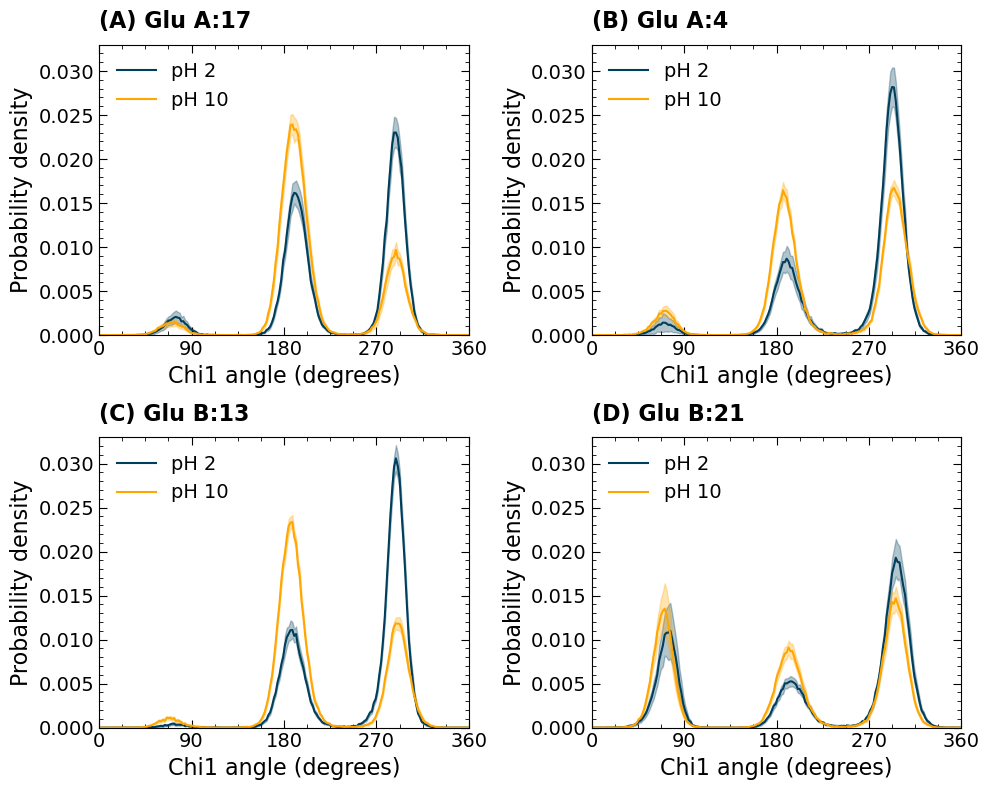

In [7]:
# -----------------------------
# Load trajectories
# -----------------------------

traj_low = md.load("monomer/4_production/pH2.0/insulin.constant_pH2.0.nc", top=topology)
traj_high = md.load("monomer/4_production/pH10.0/insulin.constant_pH10.0.nc", top=topology)

top = traj_low.topology

# -----------------------------
# Compute chi1
# -----------------------------

chi_indices, chi1_low = md.compute_chi1(traj_low)
_, chi1_high = md.compute_chi1(traj_high)

# -----------------------------
# Map chi1 entries to GLU residues using metadata
# -----------------------------

gl4_chi_indices = []
glu_labels = []

for i, (a1, a2, a3, a4) in enumerate(chi_indices):

    res = top.atom(a1).residue

    # Match against metadata top_index
    for r in glu_residues:
        if r["top_index"] == res.index:
            gl4_chi_indices.append(i)
            glu_labels.append(f"Glu {r['bio_chain']}:{r['canonical_index']}")
            break

# Ensure consistent ordering
glu_pairs = sorted(zip(gl4_chi_indices, glu_labels),
                   key=lambda x: x[1])

gl4_chi_indices = [p[0] for p in glu_pairs]
glu_labels = [p[1] for p in glu_pairs]

# -----------------------------
# Plot χ1 distributions
# -----------------------------

chi1_data_to_save = {}

bins = 200
n_blocks = 20
panel_labels = ["(A)", "(B)", "(C)", "(D)"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, chi_idx in enumerate(gl4_chi_indices):

    angles_low = np.degrees(chi1_low[:, chi_idx]) % 360
    angles_high = np.degrees(chi1_high[:, chi_idx]) % 360

    # Saving
    clean_label = glu_labels[i].replace(" ", "_").replace(":", "_")
    chi1_data_to_save[f"{clean_label}_pH2"] = angles_low
    chi1_data_to_save[f"{clean_label}_pH10"] = angles_high

    bin_centers, mean1, ci1 = block_avg_histogram(
        angles_low, n_blocks, bins=bins, hist_range=(0, 360)
    )

    _, mean2, ci2 = block_avg_histogram(
        angles_high, n_blocks, bins=bins, hist_range=(0, 360)
    )

    ax = axs[i]

    ax.plot(bin_centers, mean1, label="pH 2", color="#003f5c")
    ax.fill_between(bin_centers, mean1 - ci1, mean1 + ci1,
                    alpha=0.3, color="#003f5c")

    ax.plot(bin_centers, mean2, label="pH 10", color="#ffa600")
    ax.fill_between(bin_centers, mean2 - ci2, mean2 + ci2,
                    alpha=0.3, color="#ffa600")

    ax.set_xlim(0, 360)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_ylim(0, 0.033)
    ax.set_xlabel("Chi1 angle (degrees)", fontsize=16)
    ax.set_ylabel("Probability density", fontsize=16)

    ax.set_title(f"{panel_labels[i]} {glu_labels[i]}",
                 loc="left", fontsize=16, fontweight="bold", pad=12)

    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, direction='in')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    ax.legend(frameon=False, fontsize=14, loc='upper left')

# Unpacking the dictionary into the save function
np.savez_compressed('monomer/data/glu_chi1_data.npz', **chi1_data_to_save)

fig.tight_layout()
fig.savefig("Figures/Monomer_Glu_Chi1_Distributions.pdf", bbox_inches="tight")


## Distance analysis: B-chain helix dipole interaction (Cys B19 – Glu B21)

To investigate whether the native B-chain α-helix modulates the pK$_a$ of Glu B21, we quantify the distance between the backbone amide nitrogen of Cys B19 (located near the C-terminal end of the helix) and the side-chain C$_\delta$ atom of Glu B21.

This interaction probes the local electrostatic environment created by the helix dipole and its potential stabilization of the deprotonated glutamate state.

Distances are computed from constant-pH molecular dynamics trajectories at pH 2 and pH 10.
Probability distributions are obtained using block-averaged histograms with 95% confidence intervals.
In addition, configurational entropy differences between the two pH conditions are estimated via bootstrap resampling of the distance distributions.

Panel (A) shows the distance probability density functions, while panel (B) displays the structural context of Glu B21 within the insulin monomer.

Using residues:
Cys: {'top_index': 39, 'chain': 1, 'resSeq': 40, 'resname': 'CYS', 'display_name': 'Cys', 'oneletter': 'C', 'bio_chain': 'B', 'canonical_index': 19, 'canonical_aa': 'C', 'matches_canonical': True, 'canonical_label': 'Cys B:19'}
Glu: {'top_index': 41, 'chain': 1, 'resSeq': 42, 'resname': 'GL4', 'display_name': 'Glu', 'oneletter': 'E', 'bio_chain': 'B', 'canonical_index': 21, 'canonical_aa': 'E', 'matches_canonical': True, 'canonical_label': 'Glu B:21'}


100%|███████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:21<00:00, 462.82it/s]



== Entropy Difference ==
Mean ΔS: 0.1014 nats
95% CI: (0.0961, 0.1065) nats


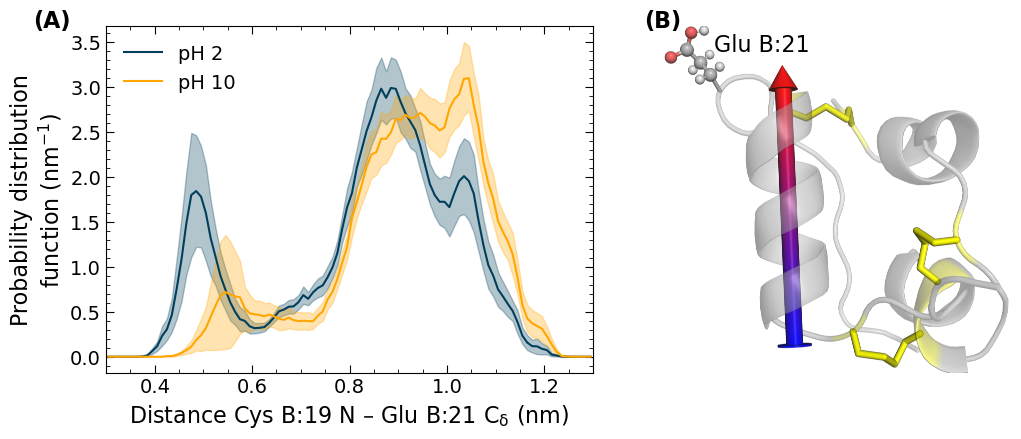

In [8]:
# -----------------------------
# Distance analysis: Cys B19 – Glu B21
# -----------------------------

# Locate residues from metadata (biological numbering)

cys = next(r for r in residue_table
           if r["bio_chain"] == "B" and r["canonical_index"] == 19)

glu = next(r for r in residue_table
           if r["bio_chain"] == "B" and r["canonical_index"] == 21)

print("Using residues:")
print("Cys:", cys)
print("Glu:", glu)

# -----------------------------
# Atom indices
# -----------------------------

cys_N = get_atom_index("CYS", cys["top_index"], "N")
glu_CD = get_atom_index(glu["resname"], glu["top_index"], "CD")  # GL4 or GLU safe

pairs = [[cys_N, glu_CD]]

# -----------------------------
# Distances
# -----------------------------

dist1 = md.compute_distances(traj_low, pairs)[:, 0]
dist2 = md.compute_distances(traj_high, pairs)[:, 0]

dist_data_to_save = {
    "CysB19_GluB21_pH2": dist1,
    "CysB19_GluB21_pH10": dist2
}
np.savez_compressed("monomer/data/distances_CysB19_GluB21.npz", **dist_data_to_save)

# -----------------------------
# Block-averaged histograms
# -----------------------------

bins = 100
hist_range = (0.3, 1.3)
n_blocks = 20

bin_centers, mean1, ci1 = block_avg_histogram(
    dist1, n_blocks, bins=bins, hist_range=hist_range
)

_, mean2, ci2 = block_avg_histogram(
    dist2, n_blocks, bins=bins, hist_range=hist_range
)

# -----------------------------
# Load structure image
# -----------------------------

img = mpimg.imread("Figures/Dipole_structure.png")

# -----------------------------
# Figure layout
# -----------------------------

fig = plt.figure(figsize=(11, 4.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.0)

# Histogram panel
ax1 = fig.add_subplot(gs[0])

ax1.plot(bin_centers, mean1, label="pH 2", color="#003f5c")
ax1.fill_between(bin_centers, mean1-ci1, mean1+ci1, alpha=0.3, color="#003f5c")

ax1.plot(bin_centers, mean2, label="pH 10", color="#ffa600")
ax1.fill_between(bin_centers, mean2-ci2, mean2+ci2, alpha=0.3, color="#ffa600")

ax1.set_xlabel("Distance Cys B:19 N – Glu B:21 C$_{\delta}$ (nm)", fontsize=16)
ax1.set_ylabel("Probability distribution\nfunction (nm$^{-1}$)", fontsize=16)

ax1.set_xlim(0.3, 1.3)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='major', labelsize=14, length=6, direction='in')
ax1.tick_params(axis='both', which='minor', length=3, direction='in')
ax1.xaxis.set_ticks_position('both')
ax1.yaxis.set_ticks_position('both')

ax1.legend(frameon=False, fontsize=14)

# Structure panel
ax2 = fig.add_subplot(gs[1])
ax2.imshow(img)
ax2.text(0.15, 0.98, "Glu B:21", transform=ax2.transAxes, fontsize=16, va='top', ha='left')
ax2.axis("off")

# Panel labels
ax1.text(-0.15, 1.05, "(A)", transform=ax1.transAxes, fontsize=16, va='top', ha='left', fontweight="bold")

ax2.text(-0.05, 1.05, "(B)", transform=ax2.transAxes, fontsize=16, va='top', ha='left', fontweight="bold")

fig.tight_layout()
fig.savefig("Figures/Monomer_CysB19_GluB21_Distance.pdf", dpi=600, bbox_inches="tight")

# ==========================================================
# Entropy calculation via bootstrap
# ==========================================================

def compute_entropy(sample, bins=100, range=(0.3, 1.3)):
    counts, _ = np.histogram(sample, bins=bins, range=range, density=True)
    counts = counts[counts > 0]
    return -np.sum(counts * np.log(counts)) * ((range[1] - range[0]) / bins)

n_bootstrap = 10000
entropy_diffs = []

for _ in trange(n_bootstrap):
    s1 = np.random.choice(dist1, size=len(dist1), replace=True)
    s2 = np.random.choice(dist2, size=len(dist2), replace=True)

    H1 = compute_entropy(s1)
    H2 = compute_entropy(s2)

    entropy_diffs.append(H1 - H2)

entropy_diffs = np.array(entropy_diffs)

mean_diff = entropy_diffs.mean()
ci_lower = np.percentile(entropy_diffs, 2.5)
ci_upper = np.percentile(entropy_diffs, 97.5)

print("\n== Entropy Difference ==")
print(f"Mean ΔS: {mean_diff:.4f} nats")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f}) nats")


### Distance analysis: Cys 40 - Glu 17

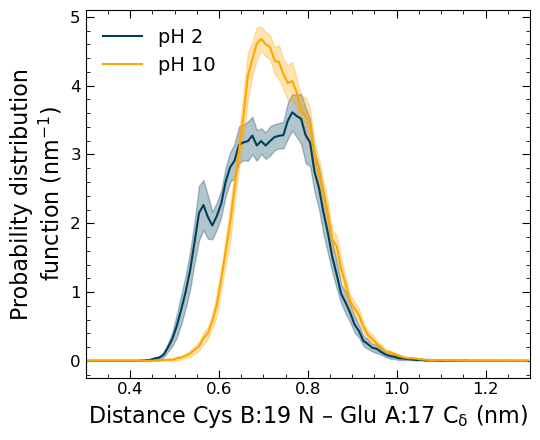

In [30]:
# -----------------------------
# Distance analysis: Cys B19 – Glu A17
# -----------------------------

top = traj_low.topology

# Locate residues from metadata
cysB19 = next(r for r in residue_table
              if r["bio_chain"] == "B" and r["canonical_index"] == 19)

gluA17 = next(r for r in residue_table
              if r["bio_chain"] == "A" and r["canonical_index"] == 17)

# Atom indices
def get_atom(res_index, atom_name):
    for a in top.residue(res_index).atoms:
        if a.name == atom_name:
            return a.index
    raise ValueError(f"Atom {atom_name} not found")

cys_N = get_atom(cysB19["top_index"], "N")
glu_CD = get_atom(gluA17["top_index"], "CD")

# Compute distances
pairs = [[cys_N, glu_CD]]

dist_low = md.compute_distances(traj_low, pairs)[:, 0]
dist_high = md.compute_distances(traj_high, pairs)[:, 0]

dist_data_A17 = {
    "CysB19_GluA17_pH2": dist_low,
    "CysB19_GluA17_pH10": dist_high
}
np.savez_compressed("monomer/data/distances_CysB19_GluA17.npz", **dist_data_A17)

# Parameters
n_blocks = 20
bins = 100
hist_range = (0.3, 1.3)

# Block-averaged histograms
bin_centers, mean1, ci1 = block_avg_histogram(
    dist_low, n_blocks, bins=bins, hist_range=hist_range
)

_, mean2, ci2 = block_avg_histogram(
    dist_high, n_blocks, bins=bins, hist_range=hist_range
)

# Plot
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(bin_centers, mean1, label="pH 2",  color="#003f5c")
ax.fill_between(bin_centers, mean1-ci1, mean1+ci1, alpha=0.3,  color="#003f5c")

ax.plot(bin_centers, mean2, label="pH 10", color="#ffa600")
ax.fill_between(bin_centers, mean2-ci2, mean2+ci2, alpha=0.3, color="#ffa600")

ax.set_xlabel("Distance Cys B:19 N – Glu A:17 C$_{\delta}$ (nm)", fontsize=16)
ax.set_ylabel("Probability distribution\nfunction (nm$^{-1}$)", fontsize=16)

ax.set_xlim(*hist_range)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
ax.tick_params(axis='both', which='minor', length=3, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax.legend(frameon=False, fontsize=14, loc='upper left')

fig.tight_layout()
fig.savefig("Figures/Monomer_CysB19_GluA17_Distance.pdf", bbox_inches="tight")


## Generating SASA data for titratable residues

We first compute the solvent accessible surface area (SASA) for all titratable residues (GLu, His, Lys, Tyr) from the production trajectories at low and high pH.

The data are computed per residue using MDTraj's `shrake_rupley` method and stored as numpy arrays for later plotting.
For large trajectories, the computation is done in chunks to save memory.

In [10]:
# Define titratable residues
TITRATABLE_RESNAMES = {"GL4", "HIS", "LYS", "TYR"}

# Map titratable residues to indices
titratable_indices = [
    res.index for res in top.residues if res.name in TITRATABLE_RESNAMES
]

chunk = 1000           # frames per chunk
TOTAL_FRAMES = 120000  # adjust if necessary

def compute_sasa_iterload(traj_file, top, label):
    sasa_chunks = []

    with tqdm(total=TOTAL_FRAMES, desc=label, unit="frames") as pbar:
        for tr in md.iterload(traj_file, top=top, chunk=chunk):
            sasa = md.shrake_rupley(tr, mode='residue')
            sasa_titr = sasa[:, titratable_indices]
            sasa_chunks.append(sasa_titr)
            pbar.update(tr.n_frames)

    return np.vstack(sasa_chunks)

# ---- Compute SASA for low and high pH ----
sasa_low = compute_sasa_iterload(
    'monomer/4_production/pH2.0/insulin.constant_pH2.0.nc',
    topology,
    'pH 2.0'
)

sasa_high = compute_sasa_iterload(
    'monomer/4_production/pH10.0/insulin.constant_pH10.0.nc',
    topology,
    'pH 10.0'
)

# Save to numpy files
np.save('monomer/data/sasa_pH2_titratable.npy', sasa_low)
np.save('monomer/data/sasa_pH10_titratable.npy', sasa_high)


pH 2.0:   0%|                                                                                            | 0/120000 [00:00<?, ?frames/s]/data9/stefan/miniconda3/envs/gaff_resp2/lib/python3.10/site-packages/mdtraj/formats/netcdf.py:154: UserWarning: Warning: The 'netCDF4' Python package is not installed. MDTraj is using the 'scipy' implementation to read and write netCDF files,which can be significantly slower.
For improved performance, consider installing netCDF4. See installation instructions at:
https://unidata.github.io/netcdf4-python/#quick-install
  warnings.warn(warning_message)
pH 10.0: 100%|█████████████████████████████████████████████████████████████████████████████| 120000/120000 [03:13<00:00, 620.03frames/s]


## SASA distributions for Glu residues

Using the pre-computed SASA numpy arrays, we focus on the Glutamate residues to investigate how solvent exposure changes with pH.
Block-averaged histograms with 95% confidence intervals are plotted for each Glu residue.

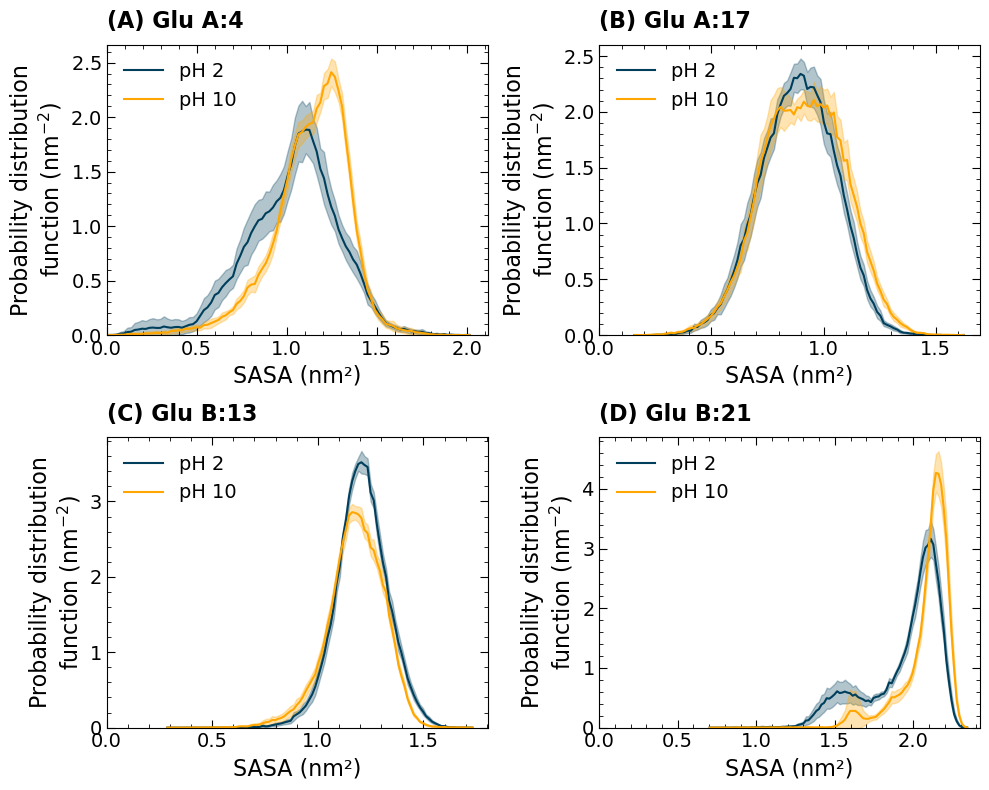

In [11]:
# Load SASA data
sasa_low = np.load('monomer/data/sasa_pH2_titratable.npy')
sasa_high = np.load('monomer/data/sasa_pH10_titratable.npy')

# Select only Glu residues
glu_indices = [
    i for i, r in enumerate(titr_res) if r["top_index"] in [g["top_index"] for g in glu_residues]
]
glu_labels = [f"Glu {r['bio_chain']}:{r['canonical_index']}" for r in glu_residues]
panel_labels = ["(A)", "(B)", "(C)", "(D)"]

# Plotting parameters
bins = 100
n_blocks = 20

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, idx in enumerate(glu_indices):
    data_low = sasa_low[:, idx]
    data_high = sasa_high[:, idx]

    # Block-averaged histograms
    bin_centers, mean_low, ci_low = block_avg_histogram(data_low, n_blocks, bins=bins)
    _, mean_high, ci_high = block_avg_histogram(data_high, n_blocks, bins=bins)

    ax = axs[i]
    ax.plot(bin_centers, mean_low, label='pH 2', color='#003f5c')
    ax.fill_between(bin_centers, mean_low - ci_low, mean_low + ci_low, color='#003f5c', alpha=0.3)

    ax.plot(bin_centers, mean_high, label='pH 10', color='#ffa600')
    ax.fill_between(bin_centers, mean_high - ci_high, mean_high + ci_high, color='#ffa600', alpha=0.3)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('SASA (nm²)', fontsize=16)
    ax.set_ylabel('Probability distribution\nfunction (nm$^{-2}$)', fontsize=16)
    ax.set_title(f"{panel_labels[i]} {glu_labels[i]}", loc='left', fontsize=16, fontweight='bold', pad=12)

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, direction='in')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    ax.legend(frameon=False, fontsize=14, loc='upper left')

fig.tight_layout()
fig.savefig("Figures/Monomer_Glu_SASA_Distributions.pdf", bbox_inches="tight")


## Mean SASA of Glutamate residues

We visualize the mean solvent accessible surface area (SASA) of the four Glu residues in insulin at low and high pH. Error bars correspond to 95% confidence intervals computed from the standard error across frames.

Alongside the bar plot, a structural figure indicates the positions of the Glu residues in the insulin monomer.

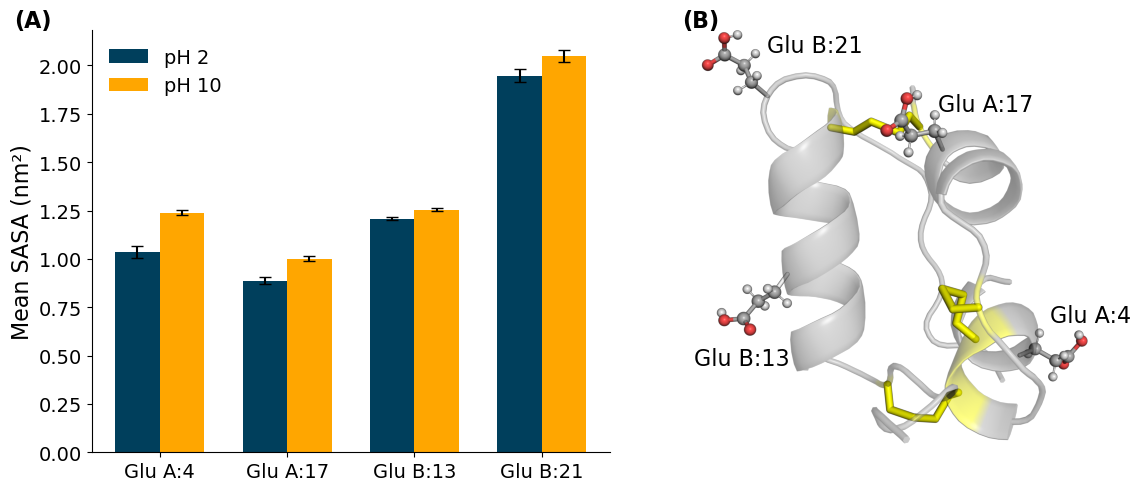

In [12]:
# -----------------------------
# Load SASA data
# -----------------------------
sasa_low = np.load('monomer/data/sasa_pH2_titratable.npy')
sasa_high = np.load('monomer/data/sasa_pH10_titratable.npy')

# Glu indices and labels
glu_indices = [
    i for i, r in enumerate(titr_res)
    if r["top_index"] in [g["top_index"] for g in glu_residues]
]
glu_labels = [f"Glu {r['bio_chain']}:{r['canonical_index']}" for r in glu_residues]

# Number of blocks for block averaging
n_blocks = 20

def block_average_sem(data, n_blocks):
    """
    Compute mean and 95% CI using block averaging along axis 0.
    data: shape (n_frames, n_residues)
    Returns: mean (n_residues,), ci95 (n_residues,)
    """
    n_frames, n_residues = data.shape
    frames_per_block = n_frames // n_blocks
    trimmed = data[:frames_per_block * n_blocks]
    blocks = trimmed.reshape(n_blocks, frames_per_block, n_residues)
    block_means = blocks.mean(axis=1)  # shape: (n_blocks, n_residues)
    mean = block_means.mean(axis=0)
    ci95 = stats.t.ppf(0.975, df=n_blocks-1) * stats.sem(block_means, axis=0)
    return mean, ci95

# -----------------------------
# Compute block-averaged mean + 95% CI
# -----------------------------
mean_low, ci_low = block_average_sem(sasa_low[:, glu_indices], n_blocks)
mean_high, ci_high = block_average_sem(sasa_high[:, glu_indices], n_blocks)

# -----------------------------
# Set up figure with bar plot + structure image
# -----------------------------
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.1], wspace=0.0)

# --- (A) Bar plot ---
ax1 = fig.add_subplot(gs[0])
x = np.arange(len(glu_indices))
width = 0.35

ax1.bar(x - width/2, mean_low, width, yerr=ci_low, label='pH 2', color='#003f5c', capsize=4)
ax1.bar(x + width/2, mean_high, width, yerr=ci_high, label='pH 10', color='#ffa600', capsize=4)

ax1.set_ylabel('Mean SASA (nm²)', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(glu_labels, fontsize=14)
ax1.legend(frameon=False, fontsize=14)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=14)

# --- (B) Structure figure ---
ax2 = fig.add_subplot(gs[1])
img = mpimg.imread('Figures/Glu_structure.png')
ax2.imshow(img)
ax2.axis('off')

# Label Glu residues on structure
positions = {
    glu_labels[0]: (0.90, 0.35),
    glu_labels[1]: (0.61, 0.85),
    glu_labels[2]: (-0.02, 0.25),
    glu_labels[3]: (0.17, 0.99),
}
for label, (xpos, ypos) in positions.items():
    ax2.text(xpos, ypos, label, transform=ax2.transAxes, fontsize=16, va='top', ha='left')

# Panel labels
ax1.text(-0.15, 1.05, r'(A)', transform=ax1.transAxes, fontsize=16, va='top', ha='left', fontweight='bold')
ax2.text(-0.05, 1.05, r'(B)', transform=ax2.transAxes, fontsize=16, va='top', ha='left', fontweight='bold')

fig.tight_layout()
fig.savefig("Figures/Monomer_Glu_SASA_Histogram.pdf", bbox_inches='tight', dpi=600)


## Global Structure

Number of native CA contacts: 105


Processing pH:   0%|                                                                                             | 0/24 [00:00<?, ?it/s]/data9/stefan/miniconda3/envs/gaff_resp2/lib/python3.10/site-packages/mdtraj/formats/netcdf.py:154: UserWarning: Warning: The 'netCDF4' Python package is not installed. MDTraj is using the 'scipy' implementation to read and write netCDF files,which can be significantly slower.
For improved performance, consider installing netCDF4. See installation instructions at:
https://unidata.github.io/netcdf4-python/#quick-install
  warnings.warn(warning_message)
Processing pH: 100%|████████████████████████████████████████████████████████████████████████████████████| 24/24 [04:03<00:00, 10.13s/it]


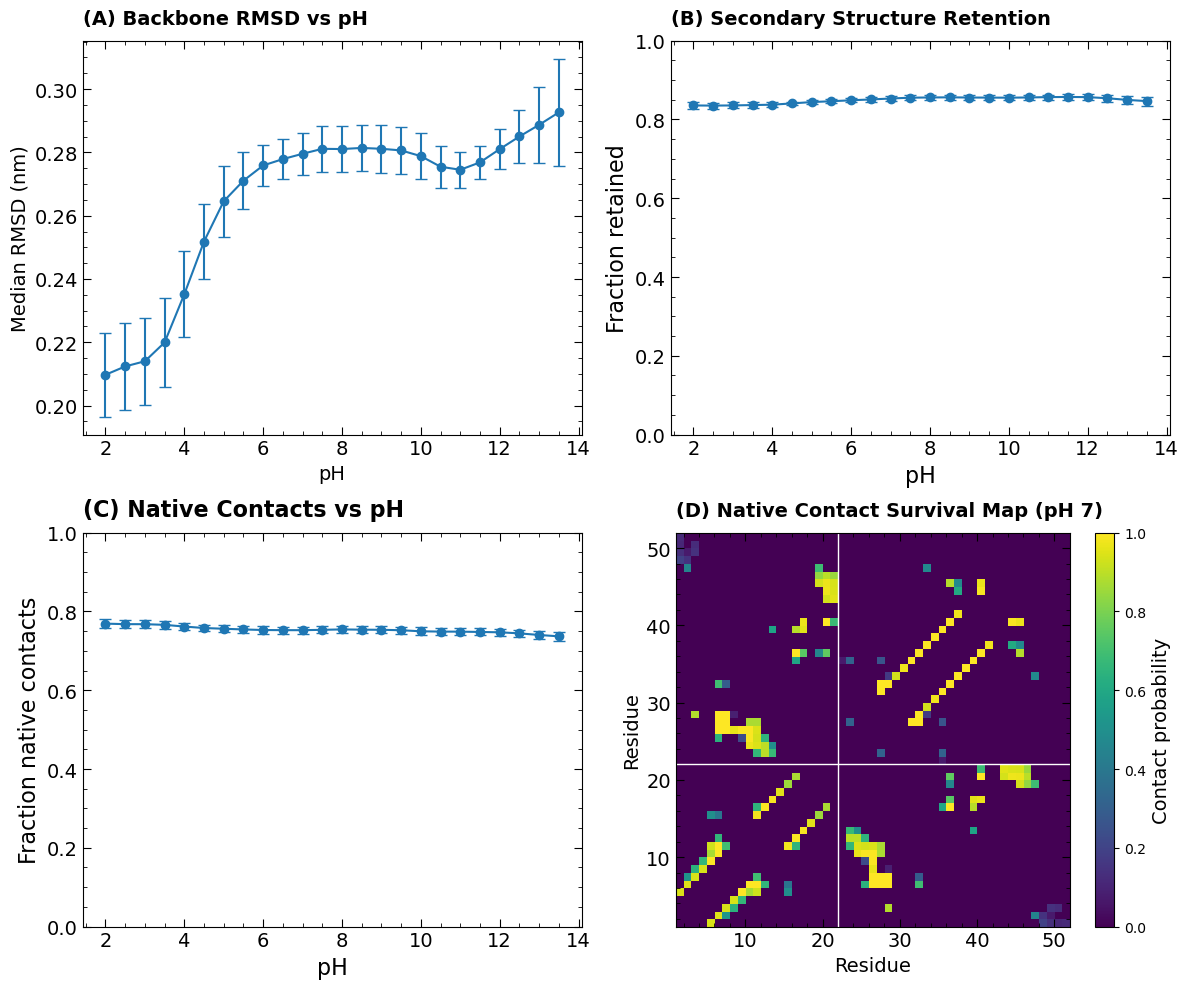

In [31]:
# -----------------------------
# Load reference structure
# -----------------------------
topology = md.load('monomer/0_preparation/insulin_leap_output.pdb')
topology.remove_solvent(inplace=True)

# backbone atoms for RMSD alignment
bb_heavy = topology.topology.select("backbone and (not element H)")

# C-alpha atoms for contact map
ca_atoms = topology.topology.select("name CA")

ref_ss = md.compute_dssp(topology, simplified=True)[0]

# -----------------------------
# Native contacts (Cα–Cα)
# -----------------------------
cutoff = 0.8   # nm (typical CA contact cutoff)
min_seq_sep = 3

residues = list(topology.topology.residues)

pairs = []
for i in range(len(ca_atoms)):
    for j in range(i+1, len(ca_atoms)):

        res_i = residues[i].index
        res_j = residues[j].index

        if abs(res_i - res_j) <= min_seq_sep:
            continue

        pairs.append((ca_atoms[i], ca_atoms[j]))

pairs = np.array(pairs)

ref_dist = md.compute_distances(topology, pairs)[0]
native_pairs = pairs[ref_dist < cutoff]

n_native = len(native_pairs)

print("Number of native CA contacts:", n_native)

# -----------------------------
# pH values
# -----------------------------
pHs = [2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,
       8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0,12.5,13.0,13.5]

# -----------------------------
# Statistics setup
# -----------------------------
n_blocks = 20
df = n_blocks - 1
t_95 = stats.t.ppf(0.975, df)

median_rmsd = []
median_err = []

ss_fraction = []
ss_err = []

q_contacts = []
q_err = []

# -----------------------------
# Contact map (pH 7 only)
# -----------------------------
n_res = topology.n_residues
contact_matrix = np.zeros((n_res, n_res))

# -----------------------------
# Main loop
# -----------------------------
for pH in tqdm(pHs, desc="Processing pH"):

    traj = md.load(
        f'monomer/4_production/pH{pH:.1f}/insulin.constant_pH{pH:.1f}.nc',
        top=topology
    )

    traj.remove_solvent(inplace=True)

    traj = traj[int(0.2 * traj.n_frames):]

    traj.superpose(topology, atom_indices=bb_heavy)

    # =============================
    # RMSD
    # =============================
    rmsd = md.rmsd(traj, topology, atom_indices=bb_heavy)

    block_size = len(rmsd) // n_blocks
    block_vals = []

    for i in range(n_blocks):

        start = i * block_size
        end = (i+1)*block_size if i < n_blocks-1 else len(rmsd)

        block_vals.append(np.median(rmsd[start:end]))

    block_vals = np.array(block_vals)

    mean_block = np.mean(block_vals)
    std_block = np.std(block_vals, ddof=1)

    err95 = t_95 * std_block / np.sqrt(n_blocks)

    median_rmsd.append(mean_block)
    median_err.append(err95)

    # =============================
    # Secondary structure
    # =============================
    traj_ss = md.compute_dssp(traj, simplified=True)

    matches = traj_ss == ref_ss
    ss_retained = matches.sum(axis=1) / matches.shape[1]

    block_size = len(ss_retained) // n_blocks
    block_vals = []

    for i in range(n_blocks):

        start = i * block_size
        end = (i+1)*block_size if i < n_blocks-1 else len(ss_retained)

        block_vals.append(np.mean(ss_retained[start:end]))

    block_vals = np.array(block_vals)

    mean_block = np.mean(block_vals)
    std_block = np.std(block_vals, ddof=1)

    err95 = t_95 * std_block / np.sqrt(n_blocks)

    ss_fraction.append(mean_block)
    ss_err.append(err95)

    # =============================
    # Native contacts Q
    # =============================
    dists = md.compute_distances(traj, native_pairs)

    contacts = dists < cutoff
    Q = contacts.sum(axis=1) / n_native

    block_size = len(Q) // n_blocks
    block_vals = []

    for i in range(n_blocks):

        start = i * block_size
        end = (i+1)*block_size if i < n_blocks-1 else len(Q)

        block_vals.append(np.mean(Q[start:end]))

    block_vals = np.array(block_vals)

    mean_block = np.mean(block_vals)
    std_block = np.std(block_vals, ddof=1)

    err95 = t_95 * std_block / np.sqrt(n_blocks)

    q_contacts.append(mean_block)
    q_err.append(err95)

    # =============================
    # Contact map (pH 7 only)
    # =============================
    if np.isclose(pH, 7.0):

        prob = contacts.mean(axis=0)

        for idx,(i,j) in enumerate(native_pairs):

            res_i = topology.topology.atom(i).residue.index
            res_j = topology.topology.atom(j).residue.index

            contact_matrix[res_i,res_j] = prob[idx]
            contact_matrix[res_j,res_i] = prob[idx]

# convert arrays
median_rmsd = np.array(median_rmsd)
median_err = np.array(median_err)

ss_fraction = np.array(ss_fraction)
ss_err = np.array(ss_err)

q_contacts = np.array(q_contacts)
q_err = np.array(q_err)

# -----------------------------
# Plot figure
# -----------------------------
fig,axs = plt.subplots(2,2,figsize=(12,10))

# RMSD
axs[0,0].errorbar(pHs,median_rmsd,yerr=median_err,marker='o',capsize=4)
axs[0,0].set_xlabel("pH", fontsize=14)
axs[0,0].set_ylabel("Median RMSD (nm)", fontsize=14)
axs[0,0].set_title("(A) Backbone RMSD vs pH", loc="left", fontsize=14, fontweight="bold", pad=12)

# Secondary structure
axs[0,1].errorbar(pHs,ss_fraction,yerr=ss_err,marker='o',capsize=4)
axs[0,1].set_xlabel("pH", fontsize=16)
axs[0,1].set_ylabel("Fraction retained", fontsize=16)
axs[0,1].set_ylim(0,1)
axs[0,1].set_title("(B) Secondary Structure Retention", loc="left", fontsize=14, fontweight="bold", pad=12)

# Native contacts
axs[1,0].errorbar(pHs,q_contacts,yerr=q_err,marker='o',capsize=4)
axs[1,0].set_xlabel("pH", fontsize=16)
axs[1,0].set_ylabel("Fraction native contacts", fontsize=16)
axs[1,0].set_ylim(0,1)
axs[1,0].set_title("(C) Native Contacts vs pH", loc="left", fontsize=16, fontweight="bold", pad=12)

# Contact map
im = axs[1,1].imshow(contact_matrix,origin='lower',vmin=0,vmax=1, extent=[1, n_res+1, 1, n_res+1])

axs[1,1].set_title("(D) Native Contact Survival Map (pH 7)", loc="left", fontsize=14, fontweight="bold", pad=12)
axs[1,1].set_xlabel("Residue", fontsize=14)
axs[1,1].set_ylabel("Residue", fontsize=14)

# draw chain boundary (insulin A/B split)
axs[1,1].axvline(22,color='white',linewidth=1)
axs[1,1].axhline(22,color='white',linewidth=1)

cbar = fig.colorbar(im,ax=axs[1,1])
cbar.set_label("Contact probability", fontsize=14)

for ax in axs.flatten():
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, direction='in')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

fig.tight_layout()
fig.savefig('Figures/Monomer_Global_Structure.pdf', )
plt.show()


# -----------------------------
# Save structural analysis data
# -----------------------------
# 1. Save all pH-dependent summary statistics
np.savez_compressed(
    'monomer/data/monomer_structural_stats.npz',
    pH_values=np.array(pHs),
    rmsd_median=median_rmsd,
    rmsd_err=median_err,
    ss_fraction=ss_fraction,
    ss_err=ss_err,
    q_contacts=q_contacts,
    q_err=q_err
)

# 2. Save the 2D contact matrix separately
np.save('monomer/data/monomer_contact_map_pH7.npy', contact_matrix)